In [12]:
# ============================================================
# NOTEBOOK HEADER (run once)
# ============================================================

import os
import json
import copy
import numpy as np

from data_handler.data_loader import load_monk
from training.model_factory import build_model_from_cfg
from training.trainer import Trainer

from testing.ensemble_utils import (
    stack_histories,
    predict_proba,
    majority_vote,
    accuracy,
    bce_loss,
    mean_std,
    plot_runs_with_mean,
)

SEEDS = [9, 11, 35, 42, 51, 68, 74, 81, 99]


##########################################################################################
### MONK1 — 10 seeds + majority vote ensemble
##########################################################################################
Train file: data/MONK/MONK1/monks-1.train
Test  file: data/MONK/MONK1/monks-1.test
X_train: (124, 17) y_train: (124, 1)
X_test : (432, 17) y_test : (432, 1)

Running 9 trainings with seeds: [9, 11, 35, 42, 51, 68, 74, 81, 99]
epochs=1000 batch_size=16 shuffle=True drop_last=False


[MONK1] RUN seed=9

      _____     ___                 _ _ _ 
      \_   \   / __\__ ___   ____ _| | (_)
       / /\/  / /  / _` \ \ / / _` | | | |
    /\/ /_   / /__| (_| |\ V / (_| | | | |
    \____/   \____/\__,_| \_/ \__,_|_|_|_|
    
Epoch 1/1000 [>.............................] loss: 0.6718 Accuracy: 0.6532 val_loss: 0.6039 val_Accuracy: 0.6782Epoch 2/1000 [>.............................] loss: 0.4856 Accuracy: 0.8226 val_loss: 0.5405 val_Accuracy: 0.7269Epoch 3/1000 [>.......

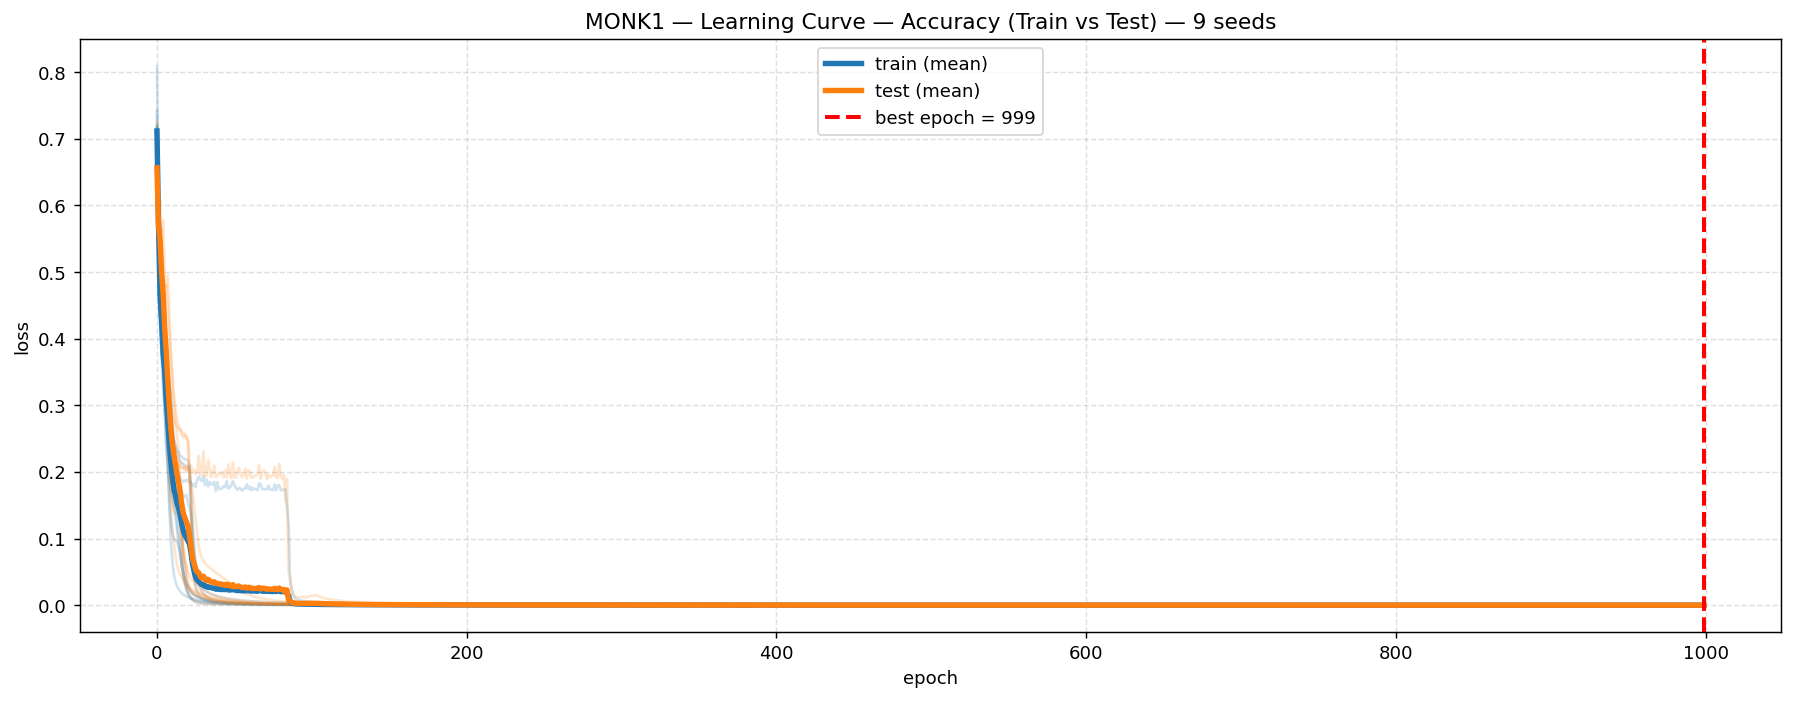

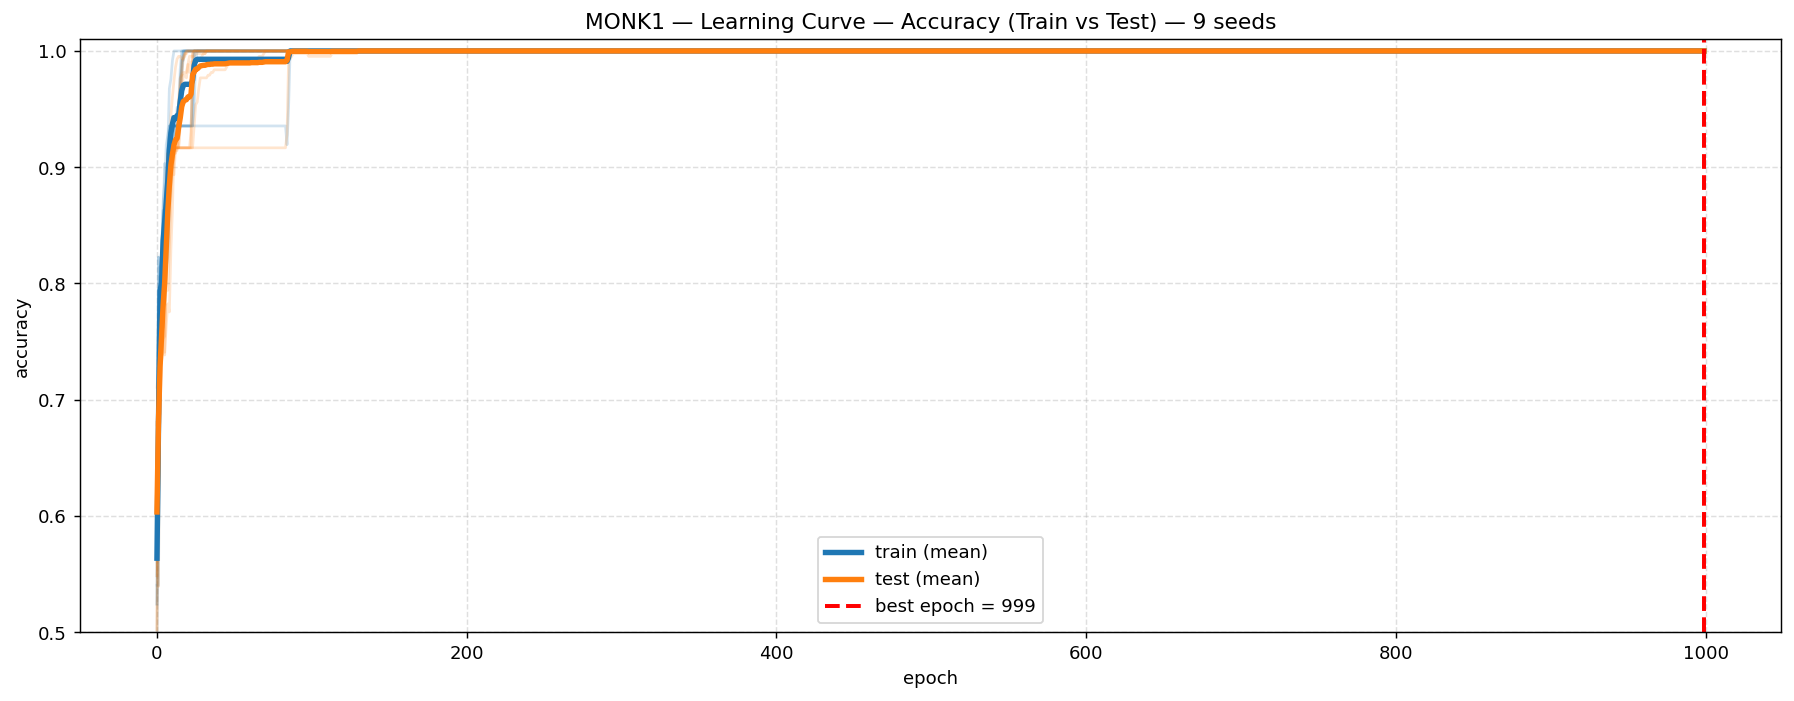

In [13]:
# ============================================================
# MONK1 — 10 seeds + majority vote ensemble + 2 figures
# ============================================================

NAME = "MONK1"
best_cfg_path = "experiments/MONK/results/monk1/best_config.json"
train_path    = "data/MONK/MONK1/monks-1.train"
test_path     = "data/MONK/MONK1/monks-1.test"

print("\n" + "#" * 90)
print(f"### {NAME} — 10 seeds + majority vote ensemble")
print("#" * 90)

# Load cfg
if not os.path.exists(best_cfg_path):
    raise FileNotFoundError(f"[{NAME}] best_config not found: {best_cfg_path}")
with open(best_cfg_path, "r") as f:
    cfg = json.load(f)

# Load data
if not os.path.exists(train_path):
    raise FileNotFoundError(f"[{NAME}] Train file not found: {train_path}")
if not os.path.exists(test_path):
    raise FileNotFoundError(f"[{NAME}] Test file not found:  {test_path}")

print("Train file:", train_path)
print("Test  file:", test_path)

X_train, y_train = load_monk(train_path, encode=True)
X_test,  y_test  = load_monk(test_path,  encode=True)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)

# Training params
epochs = int(cfg.get("training", {}).get("epochs", 1000))
batch_size = int(cfg.get("training", {}).get("batch_size", 16))
shuffle = bool(cfg.get("training", {}).get("shuffle", True))
drop_last = bool(cfg.get("training", {}).get("drop_last", False))
include_reg_in_val = bool(cfg.get("training", {}).get("include_reg_in_val", False))

print(f"\nRunning {len(SEEDS)} trainings with seeds: {SEEDS}")
print(f"epochs={epochs} batch_size={batch_size} shuffle={shuffle} drop_last={drop_last}\n")

# Train runs
all_histories, all_models, all_evals, run_lengths = [], [], [], []

for s in SEEDS:
    print("\n" + "=" * 70)
    print(f"[{NAME}] RUN seed={s}")
    print("=" * 70)

    np.random.seed(int(s))

    model = build_model_from_cfg(
        run_cfg=cfg,
        seed=int(s),
        in_dim=X_train.shape[1],
        out_dim=y_train.shape[1],
        task="binary",
    )
    trainer = Trainer(model, verbose=1)

    history = trainer.fit(
        X_train, y_train,
        X_val=X_test, y_val=y_test,
        epochs=epochs,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        seed=int(s),
        include_reg_in_val=include_reg_in_val,
    )

    hist = history.to_dict()
    all_histories.append(hist)
    all_models.append(model)

    L = len(hist.get("loss", []))
    run_lengths.append(L)
    print(f"Done. epochs_ran={L}")

    train_eval = trainer.evaluate(X_train, y_train, batch_size=256, include_regularization=True)
    test_eval  = trainer.evaluate(X_test,  y_test,  batch_size=256, include_regularization=True)

    all_evals.append({
        "seed": int(s),
        "train_loss": float(train_eval.get("loss", np.nan)),
        "train_acc":  float(train_eval.get("Accuracy", np.nan)),
        "test_loss":  float(test_eval.get("loss", np.nan)),
        "test_acc":   float(test_eval.get("Accuracy", np.nan)),
    })

print("\nEpochs per run:", run_lengths)
print("Min epochs:", min(run_lengths), "| Max epochs:", max(run_lengths))

# Ensemble
P_train = np.stack([predict_proba(m, X_train) for m in all_models], axis=0)
P_test  = np.stack([predict_proba(m, X_test)  for m in all_models], axis=0)

ytr = y_train.reshape(-1).astype(int)
yte = y_test.reshape(-1).astype(int)

yhat_tr, pmean_tr, _ = majority_vote(P_train, threshold=0.5)
yhat_te, pmean_te, _ = majority_vote(P_test,  threshold=0.5)

ens_train_acc  = accuracy(ytr, yhat_tr)
ens_test_acc   = accuracy(yte, yhat_te)
ens_train_loss = bce_loss(ytr, pmean_tr)
ens_test_loss  = bce_loss(yte, pmean_te)

print("\n================ ENSEMBLE (MAJORITY VOTE) ================")
print(f"Models: {len(all_models)}")
print(f"TRAIN BCE(mean-proba): {ens_train_loss:.6f} | acc: {ens_train_acc:.6f}")
print(f"TEST  BCE(mean-proba): {ens_test_loss:.6f} | acc: {ens_test_acc:.6f}")
print("=========================================================\n")

# Per-run summary
train_loss_mean, train_loss_std = mean_std([r["train_loss"] for r in all_evals])
test_loss_mean,  test_loss_std  = mean_std([r["test_loss"]  for r in all_evals])
train_acc_mean,  train_acc_std  = mean_std([r["train_acc"]  for r in all_evals])
test_acc_mean,   test_acc_std   = mean_std([r["test_acc"]   for r in all_evals])

print("\n================ PER-RUN RESULTS ================")
for r in all_evals:
    print(f"seed={r['seed']:>2d} | "
          f"train loss={r['train_loss']:.6f}, acc={r['train_acc']:.6f} | "
          f"test loss={r['test_loss']:.6f},  acc={r['test_acc']:.6f}")
print("=================================================\n")

print("================ SUMMARY (mean ± std) ================")
print(f"TRAIN loss: {train_loss_mean:.6f} ± {train_loss_std:.6f}")
print(f"TRAIN acc : {train_acc_mean:.6f} ± {train_acc_std:.6f}")
print(f"TEST  loss: {test_loss_mean:.6f} ± {test_loss_std:.6f}")
print(f"TEST  acc : {test_acc_mean:.6f} ± {test_acc_std:.6f}")
print("======================================================\n")

# Plots
train_losses = stack_histories(all_histories, "loss")
test_losses  = stack_histories(all_histories, "val_loss")
train_accs   = stack_histories(all_histories, "Accuracy")
test_accs    = stack_histories(all_histories, "val_Accuracy")

# stopping epoch chosen by mean validation loss
mean_val_loss = np.nanmean(test_losses, axis=0)
best_epoch_loss = int(np.nanargmin(mean_val_loss))
print("Chosen stopping epoch (val loss):", best_epoch_loss)

plot_runs_with_mean(
    train_losses, test_losses,
    title=f"{NAME} — Learning Curve — Accuracy (Train vs Test) — {len(SEEDS)} seeds",
    ylabel="loss",
    best_epoch=best_epoch_loss,
    best_mode="min",
    show_best_text=False
)

plot_runs_with_mean(
    train_accs, test_accs,
    title=f"{NAME} — Learning Curve — Accuracy (Train vs Test) — {len(SEEDS)} seeds",
    ylabel="accuracy",
    ylim=(0.5, 1.01),
    best_epoch=best_epoch_loss,
    show_best_text=False
)


##########################################################################################
### MONK2 — 10 seeds + majority vote ensemble
##########################################################################################
Train file: data/MONK/MONK2/monks-2.train
Test  file: data/MONK/MONK2/monks-2.test
X_train: (169, 17) y_train: (169, 1)
X_test : (432, 17) y_test : (432, 1)

Running 9 trainings with seeds: [9, 11, 35, 42, 51, 68, 74, 81, 99]
epochs=1000 batch_size=16 shuffle=True drop_last=False


[MONK2] RUN seed=9

      _____     ___                 _ _ _ 
      \_   \   / __\__ ___   ____ _| | (_)
       / /\/  / /  / _` \ \ / / _` | | | |
    /\/ /_   / /__| (_| |\ V / (_| | | | |
    \____/   \____/\__,_| \_/ \__,_|_|_|_|
    
Epoch 1/1000 [>.............................] loss: 0.7184 Accuracy: 0.6036 val_loss: 0.6672 val_Accuracy: 0.6019Epoch 2/1000 [>.............................] loss: 0.6540 Accuracy: 0.6036 val_loss: 0.6376 val_Accuracy: 0.6597Epoch 3/1000 [>.......

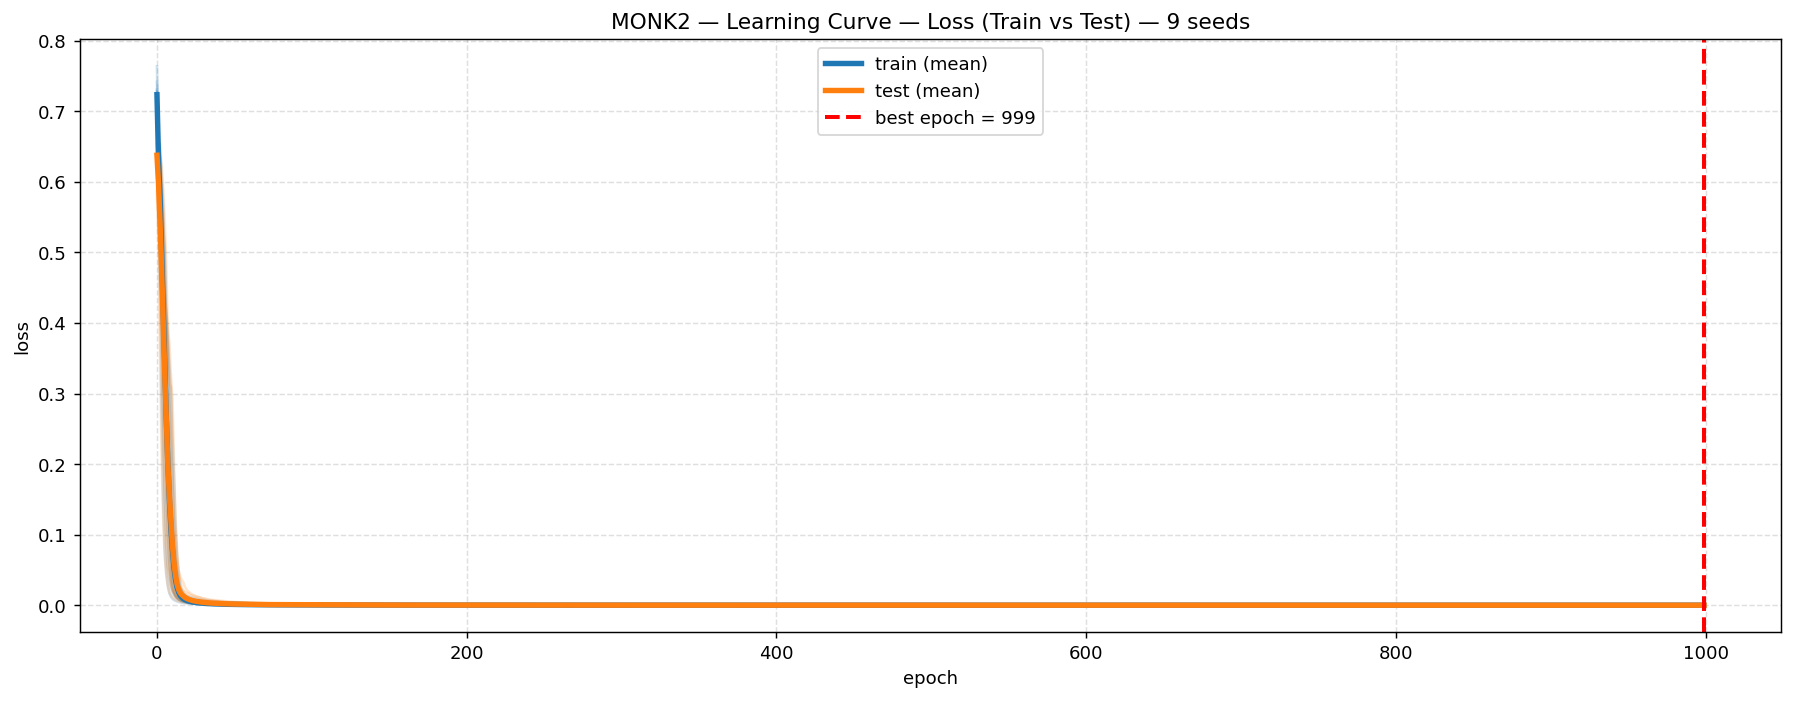

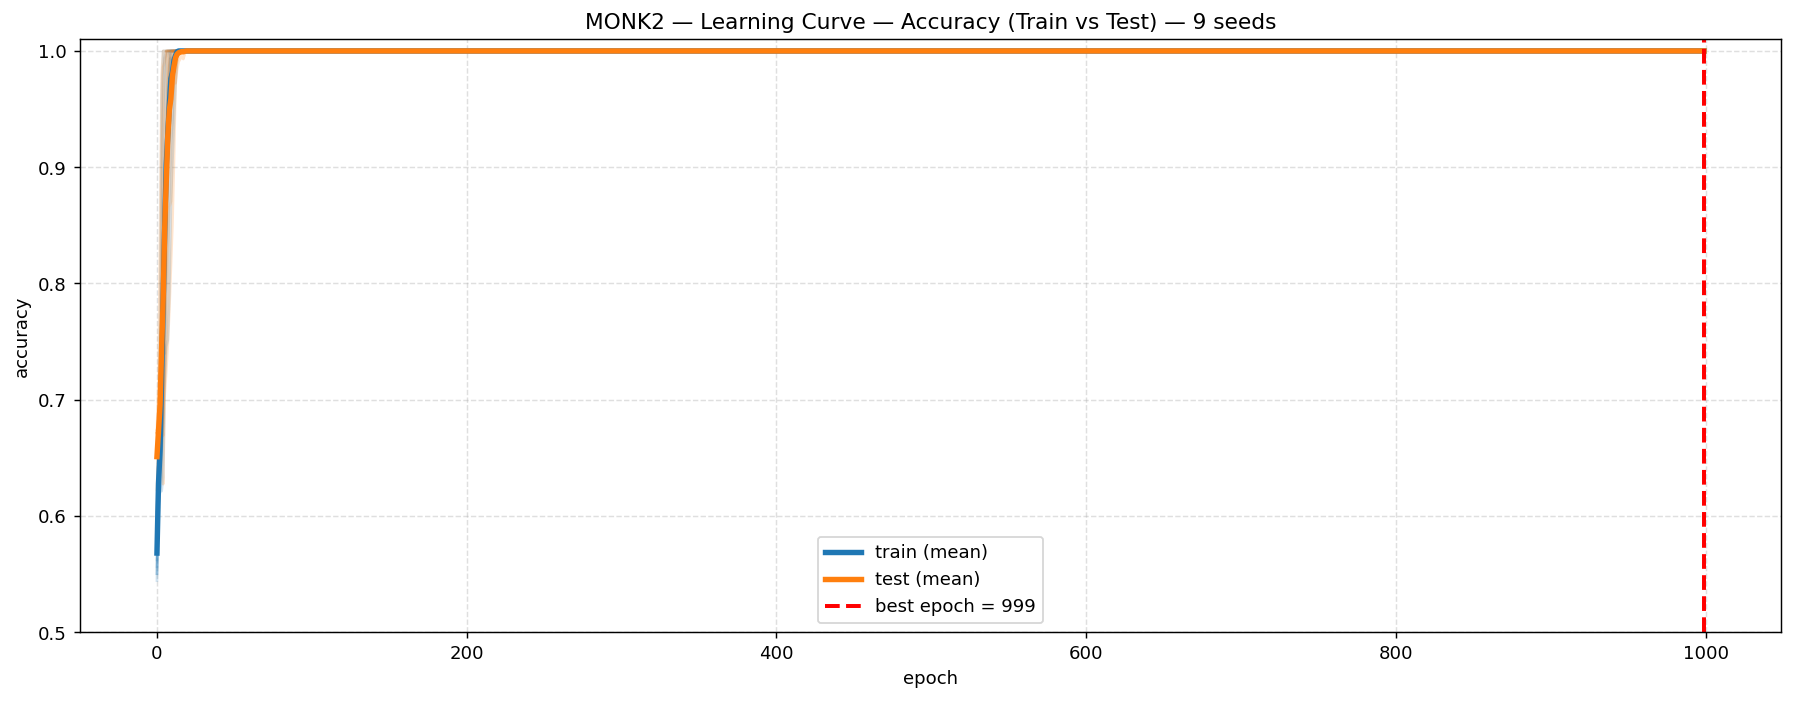

In [14]:
# ============================================================
# MONK2 — 10 seeds + majority vote ensemble + 2 figures
# ============================================================

NAME = "MONK2"
best_cfg_path = "experiments/MONK/results/monk2/best_config.json"
train_path    = "data/MONK/MONK2/monks-2.train"
test_path     = "data/MONK/MONK2/monks-2.test"

print("\n" + "#" * 90)
print(f"### {NAME} — 10 seeds + majority vote ensemble")
print("#" * 90)

if not os.path.exists(best_cfg_path):
    raise FileNotFoundError(f"[{NAME}] best_config not found: {best_cfg_path}")
with open(best_cfg_path, "r") as f:
    cfg = json.load(f)

if not os.path.exists(train_path):
    raise FileNotFoundError(f"[{NAME}] Train file not found: {train_path}")
if not os.path.exists(test_path):
    raise FileNotFoundError(f"[{NAME}] Test file not found:  {test_path}")

print("Train file:", train_path)
print("Test  file:", test_path)

X_train, y_train = load_monk(train_path, encode=True)
X_test,  y_test  = load_monk(test_path,  encode=True)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)

epochs = int(cfg.get("training", {}).get("epochs", 1000))
batch_size = int(cfg.get("training", {}).get("batch_size", 16))
shuffle = bool(cfg.get("training", {}).get("shuffle", True))
drop_last = bool(cfg.get("training", {}).get("drop_last", False))
include_reg_in_val = bool(cfg.get("training", {}).get("include_reg_in_val", False))

print(f"\nRunning {len(SEEDS)} trainings with seeds: {SEEDS}")
print(f"epochs={epochs} batch_size={batch_size} shuffle={shuffle} drop_last={drop_last}\n")

all_histories, all_models, all_evals, run_lengths = [], [], [], []

for s in SEEDS:
    print("\n" + "=" * 70)
    print(f"[{NAME}] RUN seed={s}")
    print("=" * 70)

    np.random.seed(int(s))

    model = build_model_from_cfg(
        run_cfg=cfg,
        seed=int(s),
        in_dim=X_train.shape[1],
        out_dim=y_train.shape[1],
        task="binary",
    )
    trainer = Trainer(model, verbose=1)

    history = trainer.fit(
        X_train, y_train,
        X_val=X_test, y_val=y_test,
        epochs=epochs,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        seed=int(s),
        include_reg_in_val=include_reg_in_val,
    )

    hist = history.to_dict()
    all_histories.append(hist)
    all_models.append(model)

    L = len(hist.get("loss", []))
    run_lengths.append(L)
    print(f"Done. epochs_ran={L}")

    train_eval = trainer.evaluate(X_train, y_train, batch_size=256, include_regularization=True)
    test_eval  = trainer.evaluate(X_test,  y_test,  batch_size=256, include_regularization=True)

    all_evals.append({
        "seed": int(s),
        "train_loss": float(train_eval.get("loss", np.nan)),
        "train_acc":  float(train_eval.get("Accuracy", np.nan)),
        "test_loss":  float(test_eval.get("loss", np.nan)),
        "test_acc":   float(test_eval.get("Accuracy", np.nan)),
    })

print("\nEpochs per run:", run_lengths)
print("Min epochs:", min(run_lengths), "| Max epochs:", max(run_lengths))

P_train = np.stack([predict_proba(m, X_train) for m in all_models], axis=0)
P_test  = np.stack([predict_proba(m, X_test)  for m in all_models], axis=0)

ytr = y_train.reshape(-1).astype(int)
yte = y_test.reshape(-1).astype(int)

yhat_tr, pmean_tr, _ = majority_vote(P_train, threshold=0.5)
yhat_te, pmean_te, _ = majority_vote(P_test,  threshold=0.5)

ens_train_acc  = accuracy(ytr, yhat_tr)
ens_test_acc   = accuracy(yte, yhat_te)
ens_train_loss = bce_loss(ytr, pmean_tr)
ens_test_loss  = bce_loss(yte, pmean_te)

print("\n================ ENSEMBLE (MAJORITY VOTE) ================")
print(f"Models: {len(all_models)}")
print(f"TRAIN BCE(mean-proba): {ens_train_loss:.6f} | acc: {ens_train_acc:.6f}")
print(f"TEST  BCE(mean-proba): {ens_test_loss:.6f} | acc: {ens_test_acc:.6f}")
print("=========================================================\n")

train_loss_mean, train_loss_std = mean_std([r["train_loss"] for r in all_evals])
test_loss_mean,  test_loss_std  = mean_std([r["test_loss"]  for r in all_evals])
train_acc_mean,  train_acc_std  = mean_std([r["train_acc"]  for r in all_evals])
test_acc_mean,   test_acc_std   = mean_std([r["test_acc"]   for r in all_evals])

print("\n================ PER-RUN RESULTS ================")
for r in all_evals:
    print(f"seed={r['seed']:>2d} | "
          f"train loss={r['train_loss']:.6f}, acc={r['train_acc']:.6f} | "
          f"test loss={r['test_loss']:.6f},  acc={r['test_acc']:.6f}")
print("=================================================\n")

print("================ SUMMARY (mean ± std) ================")
print(f"TRAIN loss: {train_loss_mean:.6f} ± {train_loss_std:.6f}")
print(f"TRAIN acc : {train_acc_mean:.6f} ± {train_acc_std:.6f}")
print(f"TEST  loss: {test_loss_mean:.6f} ± {test_loss_std:.6f}")
print(f"TEST  acc : {test_acc_mean:.6f} ± {test_acc_std:.6f}")
print("======================================================\n")

train_losses = stack_histories(all_histories, "loss")
test_losses  = stack_histories(all_histories, "val_loss")
train_accs   = stack_histories(all_histories, "Accuracy")
test_accs    = stack_histories(all_histories, "val_Accuracy")

# stopping epoch chosen by mean validation loss
mean_val_loss = np.nanmean(test_losses, axis=0)
best_epoch_loss = int(np.nanargmin(mean_val_loss))
print("Chosen stopping epoch (val loss):", best_epoch_loss)

plot_runs_with_mean(
    train_losses, test_losses,
    title=f"{NAME} — Learning Curve — Loss (Train vs Test) — {len(SEEDS)} seeds",
    ylabel="loss",
    best_epoch=best_epoch_loss,
    best_mode="min",
    show_best_text=False
)
plot_runs_with_mean(
    train_accs, test_accs,
    title=f"{NAME} — Learning Curve — Accuracy (Train vs Test) — {len(SEEDS)} seeds",
    ylabel="accuracy",
    ylim=(0.5, 1.01),
    best_epoch=best_epoch_loss,
    show_best_text=False
)


##########################################################################################
### MONK3 — 10 seeds + majority vote ensemble (EARLY STOP OFF)
##########################################################################################
Train file: data/MONK/MONK3/monks-3.train
Test  file: data/MONK/MONK3/monks-3.test
X_train: (122, 17) y_train: (122, 1)
X_test : (432, 17) y_test : (432, 1)

Running 9 trainings with seeds: [9, 11, 35, 42, 51, 68, 74, 81, 99]
epochs=800 batch_size=32 shuffle=True drop_last=False

NOTE: EarlyStopping disabled for MONK3 in this experiment.


[MONK3] RUN seed=9

      _____     ___                 _ _ _ 
      \_   \   / __\__ ___   ____ _| | (_)
       / /\/  / /  / _` \ \ / / _` | | | |
    /\/ /_   / /__| (_| |\ V / (_| | | | |
    \____/   \____/\__,_| \_/ \__,_|_|_|_|
    
Epoch 1/800 [>.............................] loss: 0.7501 Accuracy: 0.4344 val_loss: 0.6887 val_Accuracy: 0.4722Epoch 2/800 [>.............................] loss: 0.6754 Ac

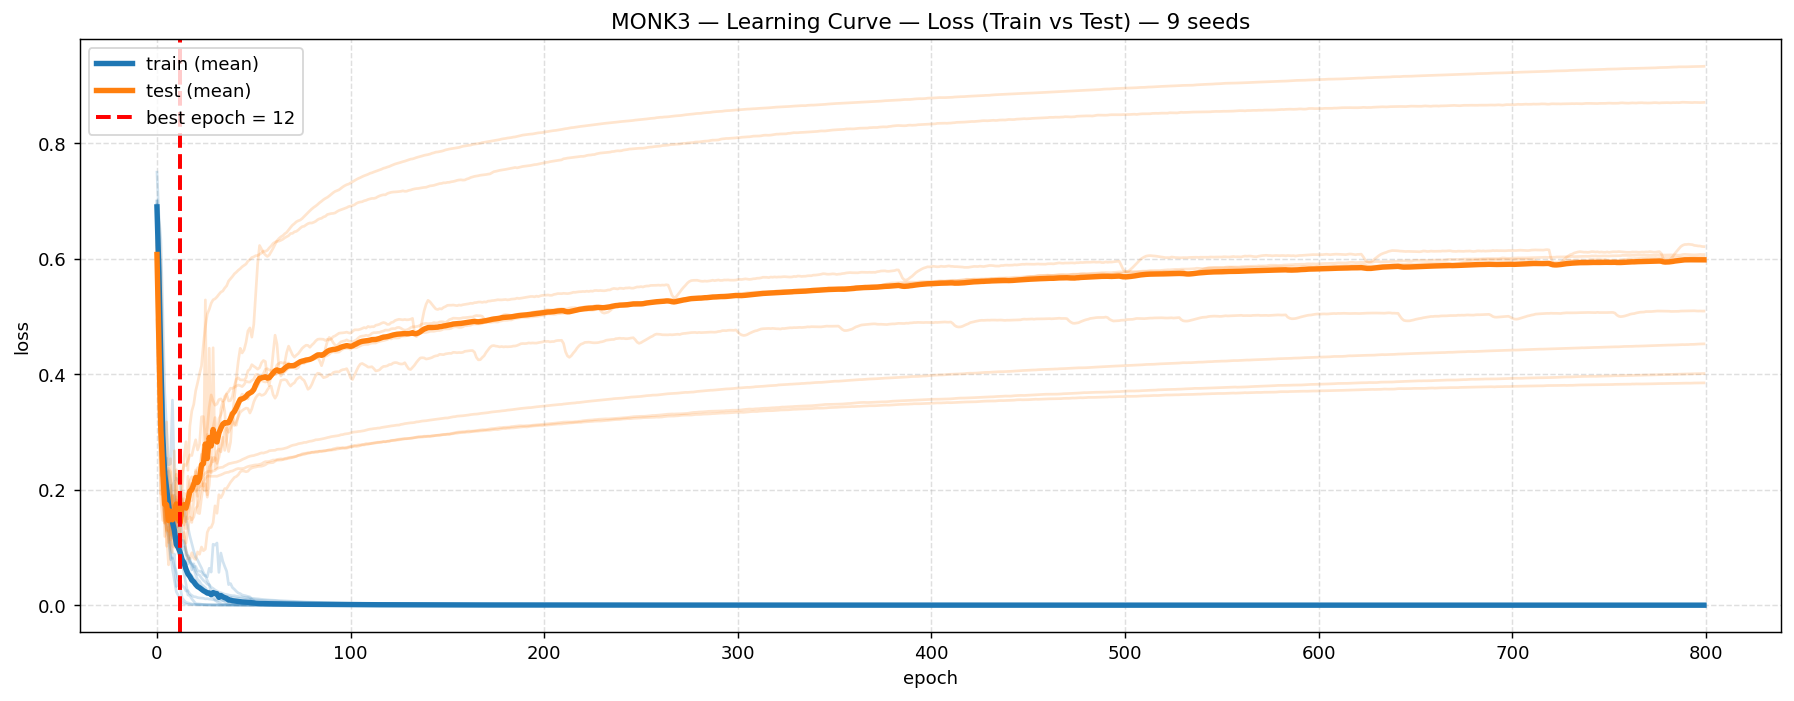

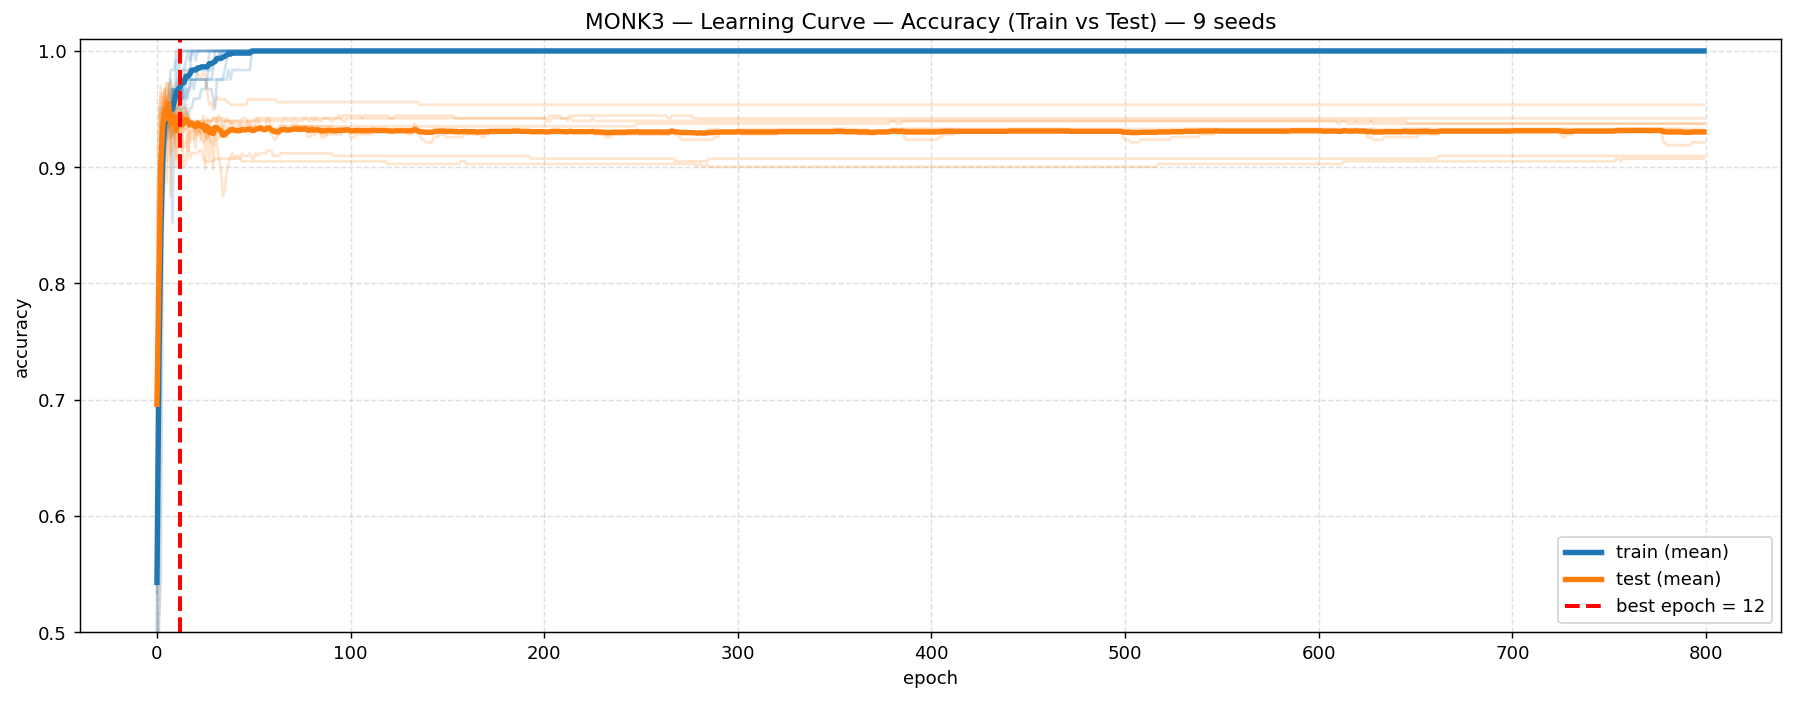

In [15]:
# ============================================================
# MONK3 — 10 seeds + majority vote ensemble + 2 figures
# FIX: disable early stopping so it runs full epochs from cfg
# ============================================================

NAME = "MONK3"
best_cfg_path = "experiments/MONK/results/monk3/best_config.json"
train_path    = "data/MONK/MONK3/monks-3.train"
test_path     = "data/MONK/MONK3/monks-3.test"

print("\n" + "#" * 90)
print(f"### {NAME} — 10 seeds + majority vote ensemble (EARLY STOP OFF)")
print("#" * 90)

if not os.path.exists(best_cfg_path):
    raise FileNotFoundError(f"[{NAME}] best_config not found: {best_cfg_path}")
with open(best_cfg_path, "r") as f:
    cfg_raw = json.load(f)

# ---- FIX HERE: copy + disable early stopping only for MONK3
cfg = copy.deepcopy(cfg_raw)
cfg.setdefault("callbacks", {})
cfg["callbacks"]["early_stopping"] = False
# (Optional) also disable reduce_lr if it exists (not required, but keeps behavior consistent)
# cfg["callbacks"]["reduce_lr_on_plateau"] = False

if not os.path.exists(train_path):
    raise FileNotFoundError(f"[{NAME}] Train file not found: {train_path}")
if not os.path.exists(test_path):
    raise FileNotFoundError(f"[{NAME}] Test file not found:  {test_path}")

print("Train file:", train_path)
print("Test  file:", test_path)

X_train, y_train = load_monk(train_path, encode=True)
X_test,  y_test  = load_monk(test_path,  encode=True)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)

epochs = int(cfg.get("training", {}).get("epochs", 1000))
batch_size = int(cfg.get("training", {}).get("batch_size", 16))
shuffle = bool(cfg.get("training", {}).get("shuffle", True))
drop_last = bool(cfg.get("training", {}).get("drop_last", False))
include_reg_in_val = bool(cfg.get("training", {}).get("include_reg_in_val", False))

print(f"\nRunning {len(SEEDS)} trainings with seeds: {SEEDS}")
print(f"epochs={epochs} batch_size={batch_size} shuffle={shuffle} drop_last={drop_last}\n")
print("NOTE: EarlyStopping disabled for MONK3 in this experiment.\n")

all_histories, all_models, all_evals, run_lengths = [], [], [], []

for s in SEEDS:
    print("\n" + "=" * 70)
    print(f"[{NAME}] RUN seed={s}")
    print("=" * 70)

    np.random.seed(int(s))

    model = build_model_from_cfg(
        run_cfg=cfg,      # <-- uses modified cfg (early stop OFF)
        seed=int(s),
        in_dim=X_train.shape[1],
        out_dim=y_train.shape[1],
        task="binary",
    )
    trainer = Trainer(model, verbose=1)

    history = trainer.fit(
        X_train, y_train,
        X_val=X_test, y_val=y_test,
        epochs=epochs,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        seed=int(s),
        include_reg_in_val=include_reg_in_val,
    )

    hist = history.to_dict()
    all_histories.append(hist)
    all_models.append(model)

    L = len(hist.get("loss", []))
    run_lengths.append(L)
    print(f"Done. epochs_ran={L}")

    train_eval = trainer.evaluate(X_train, y_train, batch_size=256, include_regularization=True)
    test_eval  = trainer.evaluate(X_test,  y_test,  batch_size=256, include_regularization=True)

    all_evals.append({
        "seed": int(s),
        "train_loss": float(train_eval.get("loss", np.nan)),
        "train_acc":  float(train_eval.get("Accuracy", np.nan)),
        "test_loss":  float(test_eval.get("loss", np.nan)),
        "test_acc":   float(test_eval.get("Accuracy", np.nan)),
    })

print("\nEpochs per run:", run_lengths)
print("Min epochs:", min(run_lengths), "| Max epochs:", max(run_lengths))

P_train = np.stack([predict_proba(m, X_train) for m in all_models], axis=0)
P_test  = np.stack([predict_proba(m, X_test)  for m in all_models], axis=0)

ytr = y_train.reshape(-1).astype(int)
yte = y_test.reshape(-1).astype(int)

yhat_tr, pmean_tr, _ = majority_vote(P_train, threshold=0.5)
yhat_te, pmean_te, _ = majority_vote(P_test,  threshold=0.5)

ens_train_acc  = accuracy(ytr, yhat_tr)
ens_test_acc   = accuracy(yte, yhat_te)
ens_train_loss = bce_loss(ytr, pmean_tr)
ens_test_loss  = bce_loss(yte, pmean_te)

print("\n================ ENSEMBLE (MAJORITY VOTE) ================")
print(f"Models: {len(all_models)}")
print(f"TRAIN BCE(mean-proba): {ens_train_loss:.6f} | acc: {ens_train_acc:.6f}")
print(f"TEST  BCE(mean-proba): {ens_test_loss:.6f} | acc: {ens_test_acc:.6f}")
print("=========================================================\n")

train_loss_mean, train_loss_std = mean_std([r["train_loss"] for r in all_evals])
test_loss_mean,  test_loss_std  = mean_std([r["test_loss"]  for r in all_evals])
train_acc_mean,  train_acc_std  = mean_std([r["train_acc"]  for r in all_evals])
test_acc_mean,   test_acc_std   = mean_std([r["test_acc"]   for r in all_evals])

print("\n================ PER-RUN RESULTS ================")
for r in all_evals:
    print(f"seed={r['seed']:>2d} | "
          f"train loss={r['train_loss']:.6f}, acc={r['train_acc']:.6f} | "
          f"test loss={r['test_loss']:.6f},  acc={r['test_acc']:.6f}")
print("=================================================\n")

print("================ SUMMARY (mean ± std) ================")
print(f"TRAIN loss: {train_loss_mean:.6f} ± {train_loss_std:.6f}")
print(f"TRAIN acc : {train_acc_mean:.6f} ± {train_acc_std:.6f}")
print(f"TEST  loss: {test_loss_mean:.6f} ± {test_loss_std:.6f}")
print(f"TEST  acc : {test_acc_mean:.6f} ± {test_acc_std:.6f}")
print("======================================================\n")

train_losses = stack_histories(all_histories, "loss")
test_losses  = stack_histories(all_histories, "val_loss")
train_accs   = stack_histories(all_histories, "Accuracy")
test_accs    = stack_histories(all_histories, "val_Accuracy")

# stopping epoch chosen by mean validation loss
mean_val_loss = np.nanmean(test_losses, axis=0)
best_epoch_loss = int(np.nanargmin(mean_val_loss))
print("Chosen stopping epoch (val loss):", best_epoch_loss)

plot_runs_with_mean(
    train_losses, test_losses,
    title=f"{NAME} — Learning Curve — Loss (Train vs Test) — {len(SEEDS)} seeds",
    ylabel="loss",
    best_epoch=best_epoch_loss,
    best_mode="min",
    show_best_text=False
)
plot_runs_with_mean(
    train_accs, test_accs,
    title=f"{NAME} — Learning Curve — Accuracy (Train vs Test) — {len(SEEDS)} seeds",
    ylabel="accuracy",
    ylim=(0.5, 1.01),
    best_epoch=best_epoch_loss,
    show_best_text=False
)